In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib


In [2]:
df = pd.read_csv("antibiotic_resistance_tracking.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (2200, 12)
Columns: ['Patient_ID', 'Age', 'Gender', 'Specimen_Type', 'Amoxicillin', 'Ciprofloxacin', 'Meropenem', 'Vancomycin', 'Colistin', 'Test_Method', 'Resistance_Genes', 'Outcome']


,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered
2,P0003,13,Female,Urine,Intermediate,Sensitive,Resistant,Intermediate,Resistant,MIC,OXA-48,ICU
3,P0004,4,Female,Sputum,Intermediate,Resistant,Sensitive,Intermediate,Intermediate,Automated System,OXA-48,ICU
4,P0005,51,Male,Urine,Resistant,Sensitive,Resistant,Intermediate,Intermediate,Automated System,NaN,ICU


In [3]:
df_long = df.melt(
    id_vars=['Patient_ID','Age','Gender','Specimen_Type','Test_Method','Resistance_Genes','Outcome'],
    value_vars=['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin'],
    var_name='Antibiotic',
    value_name='Result'
)

print("Long format shape:", df_long.shape)
df_long.head()


Long format shape: (11000, 9)


,Patient_ID,Age,Gender,Specimen_Type,Test_Method,Resistance_Genes,Outcome,Antibiotic,Result
0,P0001,36,Female,Blood,Automated System,KPC,ICU,Amoxicillin,Intermediate
1,P0002,59,Female,Blood,MIC,KPC,Recovered,Amoxicillin,Intermediate
2,P0003,13,Female,Urine,MIC,OXA-48,ICU,Amoxicillin,Intermediate
3,P0004,4,Female,Sputum,Automated System,OXA-48,ICU,Amoxicillin,Intermediate
4,P0005,51,Male,Urine,Automated System,NaN,ICU,Amoxicillin,Resistant


In [4]:
print("Unique Outcome values:", df_long['Outcome'].unique())
print(df_long['Outcome'].value_counts())


Unique Outcome values: ['ICU' 'Recovered' 'Deceased']
Outcome
ICU          3875
Recovered    3695
Deceased     3430
Name: count, dtype: int64


In [5]:
# Drop rows where Outcome is missing
df_long = df_long.dropna(subset=['Outcome'])

# Fill missing values in Age with median
df_long['Age'] = df_long['Age'].fillna(df_long['Age'].median())

# Fill missing categorical values with "Unknown"
for col in ['Gender','Specimen_Type','Test_Method','Resistance_Genes','Result','Antibiotic']:
    df_long[col] = df_long[col].fillna("Unknown")


In [6]:
# Encode Outcome (ICU/Recovered/Deceased)
df_long['Outcome'] = df_long['Outcome'].map({
    "ICU": 0,
    "Recovered": 1,
    "Deceased": 2
})

# Encode Result (feature variable)
df_long['Result'] = df_long['Result'].map({
    "Sensitive": 0,
    "Intermediate": 1,
    "Resistant": 2,
    "Unknown": -1
})

# Encode categorical features
label_encoders = {}
for col in ['Gender','Specimen_Type','Test_Method','Resistance_Genes','Antibiotic']:
    le = LabelEncoder()
    df_long[col] = le.fit_transform(df_long[col].astype(str))
    label_encoders[col] = le


In [7]:
X = df_long.drop(["Outcome","Patient_ID"], axis=1)
y = df_long["Outcome"]

print("Final samples:", df_long.shape[0])
print("Unique outcomes:", y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Final samples: 11000
Unique outcomes: [0 1 2]


In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


              precision    recall  f1-score   support

           0       0.59      0.60      0.59       797
           1       0.57      0.57      0.57       750
           2       0.52      0.50      0.51       653

    accuracy                           0.56      2200
   macro avg       0.56      0.56      0.56      2200
weighted avg       0.56      0.56      0.56      2200



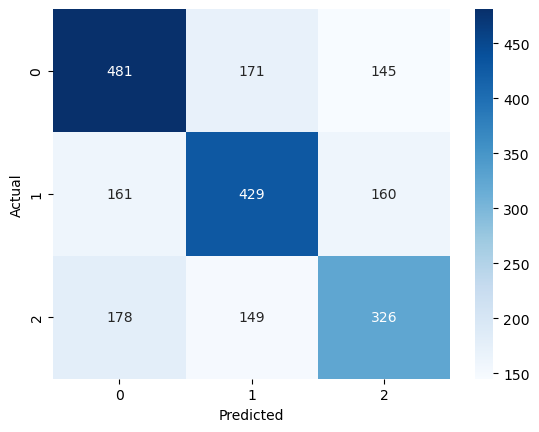

In [9]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
joblib.dump(model, "amr_prediction_model.pkl")
print("Model saved as amr_prediction_model.pkl")


Model saved as amr_prediction_model.pkl
